# Worksheet 4 – FCN for Devnagari Digit Classification
**6CS012 – AI and Machine Learning**

Building a simple neural network to classify Devnagari digits (0-9) using Keras.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from PIL import Image

# setting seeds so results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("TF version:", tf.__version__)

TF version: 2.19.0


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1: Data Preparation

Loading images from the dataset folder, converting to grayscale, resizing to 28x28, and normalising pixels to [0,1]. Labels get one-hot encoded.

Loading from: /content/drive/MyDrive/AI_Datasets/devnagari_digit/DevanagariHandwrittenDigitDataset/Train
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Loading from: /content/drive/MyDrive/AI_Datasets/devnagari_digit/DevanagariHandwrittenDigitDataset/Test
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Train: (17000, 28, 28, 1), Labels: (17000, 10)
Test : (3000, 28, 28, 1),  Labels: (3000, 10)


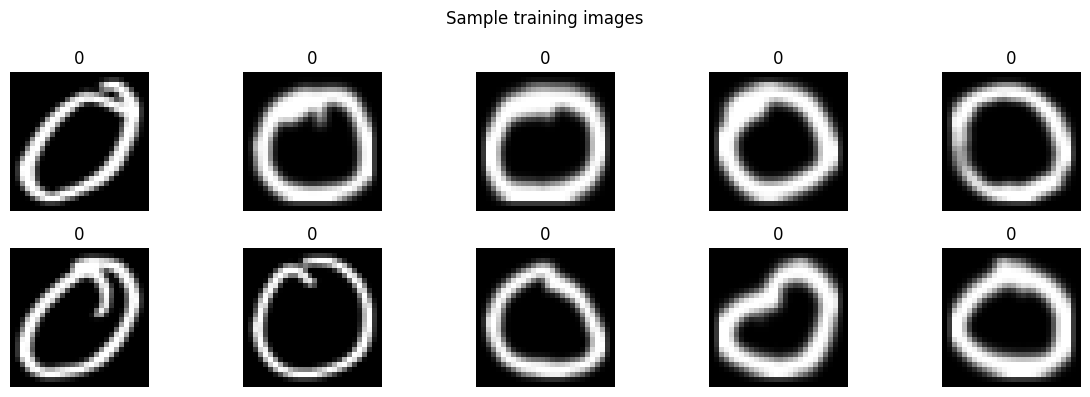

In [6]:
TRAIN_DIR   = "/content/drive/MyDrive/AI_Datasets/devnagari_digit/DevanagariHandwrittenDigitDataset/Train"
TEST_DIR    = "/content/drive/MyDrive/AI_Datasets/devnagari_digit/DevanagariHandwrittenDigitDataset/Test"
IMG_HEIGHT  = 28
IMG_WIDTH   = 28
NUM_CLASSES = 10


def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: idx for idx, name in enumerate(class_names)}

    print(f"Loading from: {folder}")
    print(f"Classes: {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")               # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))              # 28x28
                img_array = np.array(img, dtype=np.float32) / 255.0   # normalise
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)


x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)
x_test,      y_test_raw  = load_images_from_folder(TEST_DIR)

# keras needs shape (samples, H, W, channels), so add channel dimension
x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test  = x_test.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# one-hot encode: e.g. 3 -> [0,0,0,1,0,0,0,0,0,0]
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"\nTrain: {x_train.shape}, Labels: {y_train.shape}")
print(f"Test : {x_test.shape},  Labels: {y_test.shape}")

# show some sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(str(np.argmax(y_train[i])))
    plt.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

## Task 2: Build the FCN Model

Architecture: `Flatten -> Dense(64, sigmoid) -> Dense(128, sigmoid) -> Dense(256, sigmoid) -> Dense(10, softmax)`

Flatten converts 28x28 image to a 784 vector. Softmax in the last layer gives a probability for each class.

In [7]:
model = Sequential([
    keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    Flatten(),                                     # 28x28x1 -> 784

    Dense(64,  activation="sigmoid"),              # hidden layer 1
    Dense(128, activation="sigmoid"),              # hidden layer 2
    Dense(256, activation="sigmoid"),              # hidden layer 3

    Dense(NUM_CLASSES, activation="softmax"),      # output: 10 class probabilities
], name="devnagari_fcn")

model.summary()

Model: "devnagari_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

Using Adam optimizer, categorical crossentropy loss (since labels are one-hot), and tracking accuracy.

In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled!")

Model compiled!


## Task 4: Train the Model

Training for up to 20 epochs with batch size 128. 20% of training data is used for validation. EarlyStopping stops early if val_loss isn't improving, ModelCheckpoint saves the best weights.

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_fcn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining done!")

Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2712 - loss: 1.9950
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_fcn.keras

Epoch 1: finished saving model to best_devnagari_fcn.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4638 - loss: 1.6305 - val_accuracy: 0.0000e+00 - val_loss: 7.2177
Epoch 2/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8083 - loss: 0.6251
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8357 - loss: 0.5005 - val_accuracy: 0.0000e+00 - val_loss: 8.3359
Epoch 3/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9148 - loss: 0.2936
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9207 - loss: 0.2718 - val_accuracy: 0.0000e+00 - val_loss: 8.9650
Epoch 4/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9456 - loss: 0.1933
Epoch 4: val_accuracy did not improv

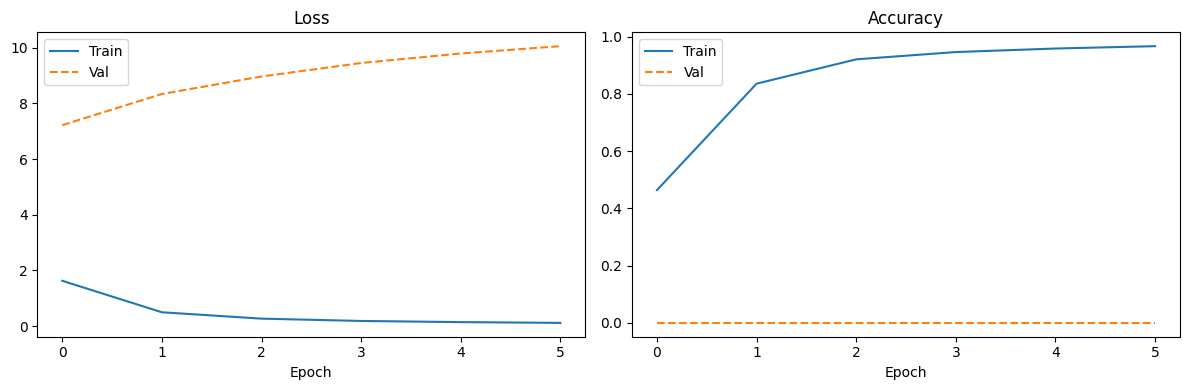

In [10]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Train")
axes[1].plot(history.history["val_accuracy"], label="Val", linestyle="--")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

Running on the test set to see how well the model generalises to unseen data.

In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

if test_acc >= 0.90:
    print("Great result!")
elif test_acc >= 0.75:
    print("Decent result, could be improved.")
else:
    print("Needs more work - try more epochs or different settings.")

94/94 - 0s - 3ms/step - accuracy: 0.6127 - loss: 2.0889

Test Loss     : 2.0889
Test Accuracy : 61.27%
Needs more work - try more epochs or different settings.


## Task 6: Save and Load the Model

Saving the trained model so we don't have to retrain from scratch every time.

In [12]:
# save
model.save("devnagari_fcn_final.h5")
print("Model saved!")

# load back
loaded_model = tf.keras.models.load_model("devnagari_fcn_final.h5")
print("Model loaded!")

# check it still gives same accuracy
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model accuracy: {loaded_acc * 100:.2f}%")

assert abs(loaded_acc - test_acc) < 1e-4, "Accuracies don't match - something went wrong!"
print("Save/load works correctly!")

Model saved!
Model loaded!
Loaded model accuracy: 61.27%
Save/load works correctly!


## Task 7: Make Predictions

`model.predict()` returns a probability for each class. We pick the highest one with `np.argmax()`.

Sample predictions:
  Image 0: True=0, Predicted=0 (56.0%) -> correct
  Image 1: True=0, Predicted=0 (54.5%) -> correct
  Image 2: True=0, Predicted=0 (59.1%) -> correct
  Image 3: True=0, Predicted=0 (59.1%) -> correct
  Image 4: True=0, Predicted=0 (59.4%) -> correct


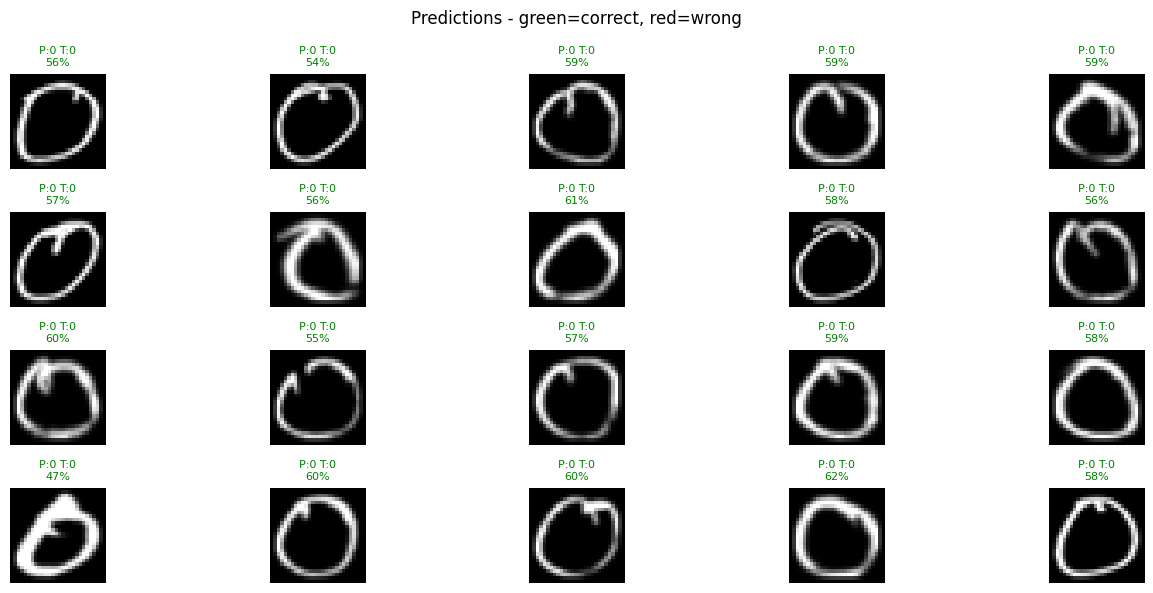


Overall accuracy: 61.27%


In [13]:
predictions = model.predict(x_test, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

# print a few
print("Sample predictions:")
for i in range(5):
    pred = predicted_labels[i]
    true = true_labels[i]
    conf = predictions[i][pred] * 100
    mark = "correct" if pred == true else "WRONG"
    print(f"  Image {i}: True={true}, Predicted={pred} ({conf:.1f}%) -> {mark}")

# visualise 20 predictions
plt.figure(figsize=(14, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    pred  = predicted_labels[i]
    true  = true_labels[i]
    conf  = predictions[i][pred] * 100
    color = "green" if pred == true else "red"

    plt.title(f"P:{pred} T:{true}\n{conf:.0f}%", color=color, fontsize=8)
    plt.axis("off")

plt.suptitle("Predictions - green=correct, red=wrong")
plt.tight_layout()
plt.show()

manual_acc = np.mean(predicted_labels == true_labels)
print(f"\nOverall accuracy: {manual_acc * 100:.2f}%")